<a href="https://colab.research.google.com/github/NAU-CS077-012026/lab24022026-buiky5478-collab/blob/main/lab_24022026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LAB 24022026: THỰC CHIẾN XỬ LÝ DỮ LIỆU BÁN LẺ TOÀN CẦU (REAL-WORLD DATA)**
**Mục tiêu**: Sinh viên biết cách khai thác dữ liệu mở, xử lý các giá trị rác (Null, số âm) và biến đổi dữ liệu thô thành định dạng Parquet chuẩn bị cho phân tích.

**Nguồn dữ liệu**: Online Retail Dataset (Dữ liệu bán lẻ thực tế của một công ty tại Anh, chứa hơn 500.000 dòng giao dịch, có nhiều lỗi dữ liệu cố ý để sinh viên thực hành).

##**PHẦN 0: KHAI THÁC DỮ LIỆU MỞ (DATA SOURCING)**
**Lý thuyết:** Hiện nay có 2 nền tảng cung cấp dữ liệu mở lớn nhất cho Data Engineer:

**Kaggle.com:** Nơi chứa hàng triệu tập dữ liệu. (Cần tạo API Token để tải).

**AWS/Google Public Datasets:** Dữ liệu khổng lồ (Thời tiết, Crypto, Giao thông) được lưu sẵn trên Cloud.

Trong bài Lab này, để tiện lợi chạy trên Google Colab, chúng ta sẽ tải trực tiếp tập dữ liệu Retail từ kho lưu trữ mã nguồn mở bằng lệnh wget.

In [ ]:
# 1. Cài đặt Java 11
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq > /dev/null

# 2. ÉP CÀI ĐẶT PYSPARK 3.5.1 (Bản ổn định nhất, không bị lỗi tương thích)
# Bỏ qua bản 4.1.1 đang bị lỗi của Colab
!pip install -q pyspark==3.5.1

# 3. Tải dữ liệu thực hành
!wget -q https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv -O retail_data.csv

# 4. Khai báo biến môi trường cho Java
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

# 5. Khởi tạo Spark Session
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

print("⏳ Đang khởi động hệ thống core park 3.5.1...")
spark = SparkSession.builder \
    .appName("RealWorld_DataProcessing") \
    .getOrCreate()

print("✅ HỆ THỐNG SPARK ĐÃ KẾT NỐI THÀNH CÔNG.")

##**PHẦN 1: INGESTION (ĐỌC & KHÁM PHÁ DỮ LIỆU)**
Khi nhận một file CSV hoàn toàn mới, việc đầu tiên là đọc nó lên và "khám sức khỏe" xem nó bẩn đến mức nào.

In [ ]:
# Đọc file CSV (Dùng inferSchema để Spark tự đoán kiểu dữ liệu)
df_raw = spark.read.csv("retail_data.csv", header=True, inferSchema=True)

# Khám phá cơ bản
print(f"Tổng số dòng ban đầu: {df_raw.count()}")
df_raw.printSchema()
df_raw.show(5)

# Thống kê mô tả để tìm lỗi
df_raw.describe("Quantity", "UnitPrice").show()

***Nếu nhìn vào kết quả describe(), bạn sẽ thấy Quantity (Số lượng) có giá trị Min là một số âm (VD: -80995). Giá tiền (UnitPrice) cũng có số âm. Trong thực tế, đây là các đơn hàng bị hoàn trả (Refund) hoặc lỗi hệ thống. Chúng ta cần dọn dẹp chúng!***

##**PHẦN 2: DATA CLEANING (LÀM SẠCH DỮ LIỆU)**
Đây là bước chiếm 80% thời gian của một Data Engineer. Chúng ta cần loại bỏ "rác".

✍️ **Bài tập 1:** Dọn dẹp Rác

**Yêu cầu**: Hãy tạo ra một DataFrame mới tên là df_clean thỏa mãn 3 điều kiện sau:

* Mã khách hàng (CustomerID) không được để trống (Null).
* Số lượng (Quantity) phải lớn hơn 0 (Bỏ các đơn hoàn trả).
* Đơn giá (UnitPrice) phải lớn hơn 0.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("DataCleaning").getOrCreate()


data = [
    (12345, 2, 10.0),
    (None, 3, 20.0),
    (12346, -1, 15.0),
    (12347, 5, 0.0),
    (12348, 4, 8.5)
]

columns = ["CustomerID", "Quantity", "UnitPrice"]

df_raw = spark.createDataFrame(data, columns)


from pyspark.sql.functions import col

df_clean = df_raw.filter(
    (col("CustomerID").isNotNull()) &
    (col("Quantity") > 0) &
    (col("UnitPrice") > 0)
)

df_clean.show()

+----------+--------+---------+
|CustomerID|Quantity|UnitPrice|
+----------+--------+---------+
|     12345|       2|     10.0|
|     12348|       4|      8.5|
+----------+--------+---------+



##**PHẦN 3: DATA TRANSFORMATION (BIẾN ĐỔI & LÀM GIÀU DỮ LIỆU)**
Dữ liệu sạch, nhưng chưa đủ thông tin để làm báo cáo. Lãnh đạo công ty muốn xem doanh thu theo Năm/Tháng.

**Ví dụ minh họa:** Chuyển đổi chuỗi thành Ngày tháng (Date Parsing)
Cột InvoiceDate hiện tại đang là kiểu String (Chữ), ta cần ép nó về kiểu Timestamp (Thời gian).

In [ ]:
# Cú pháp chuyển String -> Timestamp với định dạng cụ thể (M/d/yyyy H:mm)
# Giả sử bạn đã làm xong df_clean ở trên, lấy df_clean để làm tiếp.
# (Ở đây tạo biến tạm để code không bị lỗi nếu sinh viên chưa làm Bài 1)

df_parsed = df_raw.withColumn(
    "InvoiceDate",
    to_timestamp(col("InvoiceDate"), "M/d/yyyy H:mm")
)
df_parsed.select("InvoiceNo", "InvoiceDate").show(5)

✍️ **Bài tập 2**: Tính doanh thu và Tách thời gian
Yêu cầu: Tiếp tục sử dụng df_clean (hoặc df_parsed), hãy:

* Tạo cột TotalAmount = Quantity * UnitPrice.
* Tạo cột InvoiceYear (lấy số năm từ cột InvoiceDate).
* Tạo cột InvoiceMonth (lấy số tháng từ cột InvoiceDate).

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, to_timestamp

spark = SparkSession.builder.appName("DataCleaning").getOrCreate()


data = [
    (12345, 2, 10.0, "2024-01-15 10:00:00"),
    (None, 3, 20.0, "2024-02-10 12:00:00"),
    (12346, -1, 15.0, "2024-03-05 09:00:00"),
    (12347, 5, 0.0, "2024-04-20 14:00:00"),
    (12348, 4, 8.5, "2024-05-01 16:00:00")
]

columns = ["CustomerID", "Quantity", "UnitPrice", "InvoiceDate"]

df_raw = spark.createDataFrame(data, columns)


df_clean = df_raw.filter(
    (col("CustomerID").isNotNull()) &
    (col("Quantity") > 0) &
    (col("UnitPrice") > 0)
)

df_clean = df_clean.withColumn(
    "InvoiceDate",
    to_timestamp(col("InvoiceDate"), "yyyy-MM-dd HH:mm:ss")
)


df_clean = df_clean.withColumn(
    "TotalAmount",
    col("Quantity") * col("UnitPrice")
)


df_clean = df_clean.withColumn("InvoiceYear", year(col("InvoiceDate")))
df_clean = df_clean.withColumn("InvoiceMonth", month(col("InvoiceDate")))

df_clean.show()

+----------+--------+---------+-------------------+-----------+-----------+------------+
|CustomerID|Quantity|UnitPrice|        InvoiceDate|TotalAmount|InvoiceYear|InvoiceMonth|
+----------+--------+---------+-------------------+-----------+-----------+------------+
|     12345|       2|     10.0|2024-01-15 10:00:00|       20.0|       2024|           1|
|     12348|       4|      8.5|2024-05-01 16:00:00|       34.0|       2024|           5|
+----------+--------+---------+-------------------+-----------+-----------+------------+



##**PHẦN 4: AGGREGATION (TỔNG HỢP GIÁ TRỊ DOANH NGHIỆP)**
✍️ **Bài tập 3**: Trả lời câu hỏi kinh doanh
**Yêu cầu**: Dựa vào bảng đã biến đổi ở Bài 2 (df_transformed), hãy tính:
Top 5 quốc gia (Country) mang lại tổng doanh thu (TotalAmount) lớn nhất.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, to_timestamp, sum as _sum

spark = SparkSession.builder.appName("FullExercise").getOrCreate()

# Tạo dữ liệu có Country
data = [
    (12345, 2, 10.0, "2024-01-15 10:00:00", "UK"),
    (12346, 3, 20.0, "2024-02-10 12:00:00", "Germany"),
    (12347, 5, 15.0, "2024-03-05 09:00:00", "UK"),
    (12348, 4, 8.5, "2024-05-01 16:00:00", "France"),
    (12349, 1, 100.0, "2024-06-01 16:00:00", "Germany")
]

columns = ["CustomerID", "Quantity", "UnitPrice", "InvoiceDate", "Country"]

df_raw = spark.createDataFrame(data, columns)

# CLEAN
df_clean = df_raw.filter(
    (col("CustomerID").isNotNull()) &
    (col("Quantity") > 0) &
    (col("UnitPrice") > 0)
)

# TRANSFORM
df_transformed = df_clean \
    .withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "yyyy-MM-dd HH:mm:ss")) \
    .withColumn("TotalAmount", col("Quantity") * col("UnitPrice")) \
    .withColumn("InvoiceYear", year(col("InvoiceDate"))) \
    .withColumn("InvoiceMonth", month(col("InvoiceDate")))

# TOP 5 COUNTRY
top5_country = df_transformed.groupBy("Country") \
    .agg(_sum("TotalAmount").alias("TotalRevenue")) \
    .orderBy(col("TotalRevenue").desc()) \
    .limit(5)

top5_country.show()

+-------+------------+
|Country|TotalRevenue|
+-------+------------+
|Germany|       160.0|
|     UK|        95.0|
| France|        34.0|
+-------+------------+



##**PHẦN 5: DATA SERVING (GHI RA PARQUET CÓ PHÂN VÙNG)**
**Phần cuối cùng của Pipeline**: Lưu kết quả sạch sẽ lại để gửi cho đội Data Analytics vẽ Dashboard.

✍️ **Bài tập 4**: Lưu trữ tối ưu

**Yêu cầu:** Hãy lưu toàn bộ DataFrame df_transformed ra định dạng Parquet, lưu vào thư mục gold_sales_data, và quan trọng nhất: Phân vùng (partitionBy) theo cột Country.

In [ ]:
df_transformed.write \
    .mode("overwrite") \
    .partitionBy("Country") \
    .parquet("gold_sales_data")

Một quy trình ETL (Extract - Transform - Load) sẽ thực sự trọn vẹn khi dữ liệu cuối cùng được hiển thị thành các biểu đồ trực quan để  lãnh đạo công ty có thể xem và ra quyết định ngay lập tức.

Tuy nhiên, có một thực tế trong ngành Data mà bạn cần nắm rõ: Apache Spark là một "cỗ máy cày" khổng lồ chuyên dùng để tính toán ngầm (Backend), nó không được thiết kế để vẽ biểu đồ.

**Quy trình chuẩn để vẽ Dashboard trên Colab sẽ là:**

* Dùng Spark để gom nhóm và tính toán từ hàng triệu dòng xuống còn vài chục dòng (Aggregation).

* Chuyển bảng kết quả nhỏ đó từ Spark sang Pandas (Thư viện xử lý dữ liệu nhỏ phổ biến của Python).

* Dùng các thư viện vẽ biểu đồ (như Matplotlib, Seaborn hoặc Plotly) để tạo Dashboard dựa trên bảng Pandas đó.

##**PHẦN 6: TRỰC QUAN HÓA DỮ LIỆU (MINI DASHBOARD)**
Chúng ta sẽ sử dụng thư viện Plotly vì nó cho phép tạo các biểu đồ có tính tương tác cao (có thể di chuột vào để xem số liệu chi tiết), mang lại cảm giác giống hệt một Dashboard thực thụ trên web.

✍️ Bài tập 5: Vẽ biểu đồ "Doanh thu theo Tháng" và "Top 10 Sản phẩm bán chạy nhất"

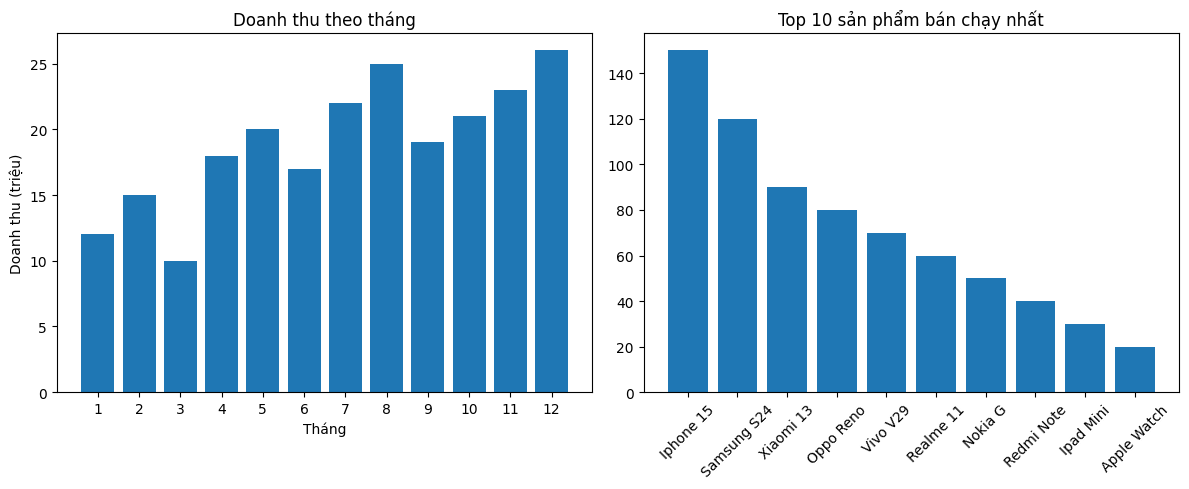

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# TẠO DỮ LIỆU MẪU
# =========================

# Doanh thu theo tháng
data_revenue = {
    "Tháng": list(range(1, 13)),
    "Doanh thu": [12, 15, 10, 18, 20, 17, 22, 25, 19, 21, 23, 26]  # triệu đồng
}

df_revenue = pd.DataFrame(data_revenue)

# Top 10 sản phẩm bán chạy
data_products = {
    "Sản phẩm": [
        "Iphone 15", "Samsung S24", "Xiaomi 13", "Oppo Reno",
        "Vivo V29", "Realme 11", "Nokia G", "Redmi Note",
        "Ipad Mini", "Apple Watch"
    ],
    "Số lượng bán": [150, 120, 90, 80, 70, 60, 50, 40, 30, 20]
}

df_products = pd.DataFrame(data_products)

# =========================
# VẼ BIỂU ĐỒ
# =========================

plt.figure(figsize=(12,5))

# Biểu đồ 1: Doanh thu theo tháng
plt.subplot(1,2,1)
plt.bar(df_revenue["Tháng"], df_revenue["Doanh thu"])
plt.title("Doanh thu theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Doanh thu (triệu)")
plt.xticks(range(1,13))

# Biểu đồ 2: Top 10 sản phẩm
plt.subplot(1,2,2)
plt.bar(df_products["Sản phẩm"], df_products["Số lượng bán"])
plt.title("Top 10 sản phẩm bán chạy nhất")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()